# 미션 10 · 3차 데이터 개선 실험 · Mac MPS 로컬판

이 notebook은 Colab GPU quota 없이 Apple Silicon Mac의 **MPS backend**에서 3차 실험을 독립 실행하기 위한 버전입니다.

## 목표

2차 실험에서 가장 좋았던 모델 구성을 고정합니다.

`FastText → Packed 2-layer BiGRU → Attention → Label smoothing 0.05`

그리고 데이터 병목만 비교합니다.

| 실험 | 전처리 | MAX_LEN | FastText |
|---|---|---:|---|
| F-local | 기존 | 300 | 기존 corpus로 로컬 재학습 |
| J | 기존 | 512 | F-local과 동일 |
| K | encoded noise 제거 | 300 | 정제 corpus로 재학습 |
| L | encoded noise 제거 | 512 | K와 동일 |

## 중요한 비교 원칙

Colab에서 학습한 F checkpoint와 로컬 MPS에서 새로 학습한 모델은 hardware·library·FastText threading 차이가 있으므로 완전한 통제 비교가 아닙니다.

따라서 이 notebook에서는 **F-local도 함께 재학습**하고, F-local·J·K·L을 동일한 Mac 환경과 seed에서 비교합니다.  
Validation Macro F1로 최종 후보를 선택한 뒤, 선택된 모델만 test set에서 한 번 평가합니다.

## 0. 로컬 환경 준비

터미널에서 새 virtual environment를 만드는 방식을 권장합니다.

```bash
cd 원하는_작업_폴더

python3 -m venv .venv
source .venv/bin/activate

python -m pip install --upgrade pip
python -m pip install \
  torch torchvision torchaudio \
  numpy pandas scipy matplotlib \
  scikit-learn gensim \
  jupyterlab ipykernel

python -m ipykernel install \
  --user \
  --name mission10-mps \
  --display-name "Python 3 (Mission10 MPS)"

jupyter lab
```

Jupyter에서 kernel을 **Python 3 (Mission10 MPS)**로 선택합니다.

### MPS 관련 설정

- `PYTORCH_ENABLE_MPS_FALLBACK=1`을 torch import 전에 설정합니다.
- MPS에서 unsupported operation이 나오면 가능한 연산만 CPU로 fallback합니다.
- `pin_memory=False`, `num_workers=0`을 사용해 Mac notebook 환경의 multiprocessing 문제를 피합니다.
- Mixed precision은 호환성 우선으로 사용하지 않습니다.

In [1]:
# torch import 전에 실행되어야 합니다.
import os

os.environ.setdefault(
    "PYTORCH_ENABLE_MPS_FALLBACK",
    "1",
)

print(
    "PYTORCH_ENABLE_MPS_FALLBACK =",
    os.environ["PYTORCH_ENABLE_MPS_FALLBACK"],
)

PYTORCH_ENABLE_MPS_FALLBACK = 1


## 1. Import와 MPS 확인

In [2]:
import gc
import json
import os
import platform
import random
import re
import sys
import time
import warnings

from collections import Counter
from pathlib import Path

try:
    import numpy as np
    import pandas as pd
    import scipy
    import matplotlib.pyplot as plt

    import torch
    import torch.nn as nn

    from gensim.models import FastText
    from IPython.display import display, Markdown
    from sklearn.datasets import fetch_20newsgroups
    from sklearn.metrics import (
        accuracy_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay,
        precision_recall_fscore_support,
    )
    from sklearn.model_selection import train_test_split
    from torch.nn.utils.rnn import (
        pad_sequence,
        pack_padded_sequence,
        pad_packed_sequence,
    )
    from torch.utils.data import Dataset, DataLoader

except Exception as error:
    raise RuntimeError(
        "필수 package import에 실패했습니다. "
        "0번 환경 준비 명령으로 새 virtual environment를 만든 뒤 "
        "해당 kernel을 선택하세요."
    ) from error

warnings.filterwarnings("ignore")

print("Python:", sys.version.split()[0])
print("Machine:", platform.machine())
print("macOS:", platform.mac_ver()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("PyTorch:", torch.__version__)
print("MPS built:", torch.backends.mps.is_built())
print("MPS available:", torch.backends.mps.is_available())

Duplicate key in file PosixPath('/Users/pio/.DataAnalysis/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc'), line 815 ('font.family : AppleGothic')
Duplicate key in file PosixPath('/Users/pio/.DataAnalysis/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc'), line 816 ('axes.unicode_minus : False')


Python: 3.11.15
Machine: arm64
macOS: 26.4.1
NumPy: 2.4.4
Pandas: 2.3.3
SciPy: 1.17.1
PyTorch: 2.12.0
MPS built: True
MPS available: True


## 2. 실험 설정

기본 batch는 32이고 gradient accumulation 4회를 사용하므로 effective batch size는 128입니다.

MPS out-of-memory가 발생하면:

```python
BATCH_SIZE = 16
GRAD_ACCUMULATION_STEPS = 8
```

로 변경하면 effective batch size를 유지할 수 있습니다.

In [3]:
SEED = 42
FAST_DEV_RUN = False

# 데이터
TEST_SIZE = 0.15
VAL_SIZE = 0.15
MIN_FREQ = 2
MAX_VOCAB_SIZE = 40_000

# FastText
EMBED_DIM = 100
FASTTEXT_EPOCHS = 10 if not FAST_DEV_RUN else 2
FASTTEXT_WORKERS = min(
    4,
    max((os.cpu_count() or 2) - 1, 1),
)

# 모델
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.4
LABEL_SMOOTHING = 0.05

# MPS 메모리 친화 설정
BATCH_SIZE = 32
GRAD_ACCUMULATION_STEPS = 4
NUM_WORKERS = 0
PIN_MEMORY = False

LEARNING_RATE = 2e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 12 if not FAST_DEV_RUN else 1
PATIENCE = 4
MIN_DELTA = 1e-4

RUN_EXPERIMENTS = [
    "F_local_original_300",
    "J_original_512",
    "K_clean_300",
    "L_clean_512",
]

SKIP_COMPLETED_EXPERIMENTS = True

OUTPUT_DIR = (
    Path.cwd()
    / "mission10_stage3_mps_outputs"
)
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
RESULT_DIR = OUTPUT_DIR / "results"
CACHE_DIR = OUTPUT_DIR / "cache"

for directory in [
    OUTPUT_DIR,
    CHECKPOINT_DIR,
    RESULT_DIR,
    CACHE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    if (
        hasattr(torch, "mps")
        and hasattr(torch.mps, "manual_seed")
    ):
        try:
            torch.mps.manual_seed(seed)
        except Exception:
            pass


def release_accelerator_memory():
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if (
        hasattr(torch, "mps")
        and hasattr(torch.mps, "empty_cache")
    ):
        try:
            torch.mps.empty_cache()
        except Exception:
            pass


seed_everything(SEED)

print("DEVICE:", DEVICE)
print(
    "Effective batch size:",
    BATCH_SIZE
    * GRAD_ACCUMULATION_STEPS,
)
print("Output directory:", OUTPUT_DIR.resolve())

if DEVICE.type != "mps":
    print(
        "경고: 현재 MPS가 활성화되지 않았습니다. "
        "Apple Silicon Mac과 MPS 지원 PyTorch인지 확인하세요."
    )

DEVICE: mps
Effective batch size: 128
Output directory: /Users/pio/Documents/AIENGINEERCOURSE/sprint_mission/mission10/mission10_stage3_mps_outputs


## 3. MPS smoke test

작은 matrix 연산을 MPS에서 실행합니다.

In [4]:
smoke_x = torch.randn(
    128,
    128,
    device=DEVICE,
)
smoke_y = smoke_x @ smoke_x.T
smoke_value = smoke_y.mean().item()

print("Smoke test device:", smoke_y.device)
print("Smoke test value:", smoke_value)

del smoke_x, smoke_y
release_accelerator_memory()

Smoke test device: mps:0
Smoke test value: 1.0730268955230713


## 4. 20 Newsgroups 로드와 동일 split 재현

기존 notebook과 같은 조건입니다.

- 전체 18,846개 문서
- header, footer, quote 제거
- seed 42
- train 70%, validation 15%, test 15%
- stratified split

In [5]:
news_data = fetch_20newsgroups(
    subset="all",
    remove=(
        "headers",
        "footers",
        "quotes",
    ),
    shuffle=True,
    random_state=SEED,
)

texts = np.asarray(
    news_data.data,
    dtype=object,
)
labels = np.asarray(
    news_data.target,
    dtype=np.int64,
)
target_names = list(
    news_data.target_names
)

train_texts, temporary_texts, train_labels, temporary_labels = (
    train_test_split(
        texts,
        labels,
        test_size=VAL_SIZE + TEST_SIZE,
        random_state=SEED,
        stratify=labels,
    )
)

relative_test_size = (
    TEST_SIZE
    / (VAL_SIZE + TEST_SIZE)
)

val_texts, test_texts, val_labels, test_labels = (
    train_test_split(
        temporary_texts,
        temporary_labels,
        test_size=relative_test_size,
        random_state=SEED,
        stratify=temporary_labels,
    )
)

if FAST_DEV_RUN:
    train_texts = train_texts[:2000]
    train_labels = train_labels[:2000]
    val_texts = val_texts[:500]
    val_labels = val_labels[:500]
    test_texts = test_texts[:500]
    test_labels = test_labels[:500]

print("전체:", len(texts))
print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))
print("Classes:", len(target_names))

전체: 18846
Train: 13192
Validation: 2827
Test: 2827
Classes: 20


## 5. 기존 전처리와 encoded-noise 전처리

In [6]:
TOKEN_PATTERN = re.compile(
    r"[a-z]+(?:'[a-z]+)?"
)

UUENCODE_BEGIN_PATTERN = re.compile(
    r"^\s*begin\s+[0-7]{3}\s+\S+",
    flags=re.IGNORECASE,
)
UUENCODE_END_PATTERN = re.compile(
    r"^\s*end\s*$",
    flags=re.IGNORECASE,
)
BASE64_LINE_PATTERN = re.compile(
    r"^[A-Za-z0-9+/=]+$"
)


def tokenize_original(text):
    text = text.lower()

    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text,
    )
    text = re.sub(
        r"\b[\w.\-+]+@[\w.\-]+\.\w+\b",
        " ",
        text,
    )
    text = re.sub(
        r"[^a-z'\s]",
        " ",
        text,
    )
    text = re.sub(
        r"\s+",
        " ",
        text,
    ).strip()

    return TOKEN_PATTERN.findall(text)


def looks_like_encoded_line(line):
    stripped = line.strip()

    if len(stripped) < 80:
        return False

    compact = re.sub(
        r"\s+",
        "",
        stripped,
    )

    if len(compact) < 80:
        return False

    base64_like = (
        len(compact) >= 100
        and BASE64_LINE_PATTERN.fullmatch(
            compact
        )
        is not None
    )

    symbol_count = sum(
        not character.isalnum()
        for character in compact
    )
    symbol_ratio = (
        symbol_count
        / max(len(compact), 1)
    )

    uuencode_like = (
        stripped.startswith("M")
        and len(compact) >= 60
        and symbol_ratio >= 0.20
    )

    symbol_heavy = (
        len(compact) >= 120
        and symbol_ratio >= 0.35
    )

    return (
        base64_like
        or uuencode_like
        or symbol_heavy
    )


def remove_encoded_payload(text):
    retained_lines = []
    inside_uuencode_block = False

    for line in text.splitlines():
        if UUENCODE_BEGIN_PATTERN.match(
            line
        ):
            inside_uuencode_block = True
            continue

        if inside_uuencode_block:
            if UUENCODE_END_PATTERN.match(
                line
            ):
                inside_uuencode_block = False
            continue

        if looks_like_encoded_line(line):
            continue

        retained_lines.append(line)

    return "\n".join(retained_lines)


def tokenize_clean(text):
    text = remove_encoded_payload(text)
    tokens = tokenize_original(text)

    token_counts = Counter(tokens)

    repeated_short_noise = {
        token
        for token, count
        in token_counts.items()
        if (
            len(token) <= 2
            and count >= 20
            and (
                count
                / max(len(tokens), 1)
            ) >= 0.20
        )
    }

    if token_counts.get("ax", 0) >= 8:
        repeated_short_noise.add("ax")

    if repeated_short_noise:
        tokens = [
            token
            for token in tokens
            if token
            not in repeated_short_noise
        ]

    return tokens

## 6. Tokenization과 데이터 진단

In [7]:
original_train_tokens = [
    tokenize_original(text)
    for text in train_texts
]
original_val_tokens = [
    tokenize_original(text)
    for text in val_texts
]
original_test_tokens = [
    tokenize_original(text)
    for text in test_texts
]

clean_train_tokens = [
    tokenize_clean(text)
    for text in train_texts
]
clean_val_tokens = [
    tokenize_clean(text)
    for text in val_texts
]
clean_test_tokens = [
    tokenize_clean(text)
    for text in test_texts
]


def token_diagnostics(
    tokenized_documents,
    max_len,
):
    lengths = np.asarray(
        [
            len(tokens)
            for tokens
            in tokenized_documents
        ]
    )

    counter = Counter(
        token
        for document
        in tokenized_documents
        for token in document
    )

    return {
        "documents": len(
            tokenized_documents
        ),
        "total_tokens": int(
            lengths.sum()
        ),
        "mean_tokens": float(
            lengths.mean()
        ),
        "median_tokens": float(
            np.median(lengths)
        ),
        "empty_ratio": float(
            np.mean(lengths == 0)
        ),
        "truncated_ratio": float(
            np.mean(lengths > max_len)
        ),
        "ax_count": int(
            counter.get("ax", 0)
        ),
    }


diagnostic_rows = []

for token_source_name, token_source in [
    (
        "original_train",
        original_train_tokens,
    ),
    (
        "clean_train",
        clean_train_tokens,
    ),
]:
    for max_len in [300, 512]:
        row = token_diagnostics(
            token_source,
            max_len,
        )
        row["token_source"] = (
            token_source_name
        )
        row["max_len"] = max_len
        diagnostic_rows.append(row)

diagnostics_df = pd.DataFrame(
    diagnostic_rows
)

display(
    diagnostics_df.style.format(
        {
            "mean_tokens": "{:.2f}",
            "median_tokens": "{:.1f}",
            "empty_ratio": "{:.2%}",
            "truncated_ratio": "{:.2%}",
        }
    )
)

print(
    "기존 상위 token:",
    Counter(
        token
        for document
        in original_train_tokens
        for token in document
    ).most_common(20),
)

print(
    "\n정제 상위 token:",
    Counter(
        token
        for document
        in clean_train_tokens
        for token in document
    ).most_common(20),
)

,documents,total_tokens,mean_tokens,median_tokens,empty_ratio,truncated_ratio,ax_count,token_source,max_len
0,13192,2601932,197.24,80.0,2.73%,11.23%,58829,original_train,300
1,13192,2601932,197.24,80.0,2.73%,5.56%,58829,original_train,512
2,13192,2466332,186.96,80.0,2.74%,11.19%,26,clean_train,300
3,13192,2466332,186.96,80.0,2.74%,5.52%,26,clean_train,512


기존 상위 token: [('the', 122935), ('to', 61202), ('ax', 58829), ('a', 55942), ('of', 54768), ('and', 49560), ('i', 38534), ('in', 35843), ('is', 35096), ('that', 31477), ('it', 24156), ('for', 23081), ('you', 19876), ('this', 16656), ('on', 16553), ('be', 15521), ('have', 15128), ('are', 14783), ('with', 14714), ('not', 14659)]

정제 상위 token: [('the', 122929), ('to', 61158), ('of', 54737), ('a', 54459), ('and', 49558), ('i', 36849), ('in', 35826), ('is', 35056), ('that', 31477), ('it', 24140), ('for', 23080), ('you', 19874), ('this', 16656), ('on', 16531), ('be', 15494), ('have', 15128), ('are', 14782), ('with', 14714), ('not', 14659), ('as', 13385)]


## 7. Vocabulary와 FastText 준비

Original corpus와 clean corpus 각각에 대해 train split만 사용합니다.

FastText는 CPU에서 학습됩니다. 학습이 끝난 뒤 neural classifier는 MPS에서 학습됩니다.

In [8]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
PAD_IDX = 0
UNK_IDX = 1


def build_vocabulary(
    train_token_documents,
):
    counter = Counter(
        token
        for document
        in train_token_documents
        for token in document
    )

    common_tokens = [
        token
        for token, frequency
        in counter.most_common(
            MAX_VOCAB_SIZE - 2
        )
        if frequency >= MIN_FREQ
    ]

    itos = [
        PAD_TOKEN,
        UNK_TOKEN,
    ] + common_tokens

    stoi = {
        token: index
        for index, token
        in enumerate(itos)
    }

    return stoi, itos, counter


def train_or_load_fasttext(
    token_documents,
    model_path,
):
    if model_path.exists():
        print(
            "FastText cache load:",
            model_path,
        )
        return FastText.load(
            str(model_path)
        )

    print(
        "FastText train:",
        model_path.name,
    )

    model = FastText(
        sentences=token_documents,
        vector_size=EMBED_DIM,
        window=5,
        min_count=MIN_FREQ,
        workers=FASTTEXT_WORKERS,
        sg=1,
        negative=10,
        epochs=FASTTEXT_EPOCHS,
        seed=SEED,
    )

    model.save(
        str(model_path)
    )

    return model


def build_embedding_matrix(
    fasttext_model,
    stoi,
):
    rng = np.random.default_rng(SEED)

    matrix = rng.normal(
        loc=0.0,
        scale=0.05,
        size=(
            len(stoi),
            EMBED_DIM,
        ),
    ).astype(np.float32)

    matrix[PAD_IDX] = 0.0

    for token, index in stoi.items():
        if index in (
            PAD_IDX,
            UNK_IDX,
        ):
            continue

        matrix[index] = (
            fasttext_model.wv.get_vector(
                token
            )
        )

    return matrix


(
    original_stoi,
    original_itos,
    original_counter,
) = build_vocabulary(
    original_train_tokens
)

(
    clean_stoi,
    clean_itos,
    clean_counter,
) = build_vocabulary(
    clean_train_tokens
)

original_fasttext = train_or_load_fasttext(
    original_train_tokens,
    CACHE_DIR / "fasttext_original.model",
)

clean_fasttext = train_or_load_fasttext(
    clean_train_tokens,
    CACHE_DIR / "fasttext_clean.model",
)

original_embedding_matrix = (
    build_embedding_matrix(
        original_fasttext,
        original_stoi,
    )
)

clean_embedding_matrix = (
    build_embedding_matrix(
        clean_fasttext,
        clean_stoi,
    )
)

print(
    "Original vocabulary:",
    len(original_stoi),
)
print(
    "Clean vocabulary:",
    len(clean_stoi),
)
print(
    "Original matrix:",
    original_embedding_matrix.shape,
)
print(
    "Clean matrix:",
    clean_embedding_matrix.shape,
)

FastText train: fasttext_original.model


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


FastText train: fasttext_clean.model


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Original vocabulary: 40000
Clean vocabulary: 40000
Original matrix: (40000, 100)
Clean matrix: (40000, 100)


## 8. Dataset과 DataLoader

MPS notebook 안정성을 위해:

- `num_workers=0`
- `pin_memory=False`
- tensor 이동 시 `non_blocking` 미사용

In [9]:
def encode_documents(
    tokenized_documents,
    vocabulary,
    max_len,
):
    encoded_documents = []

    for tokens in tokenized_documents:
        token_ids = [
            vocabulary.get(
                token,
                UNK_IDX,
            )
            for token in tokens[:max_len]
        ]

        if not token_ids:
            token_ids = [UNK_IDX]

        encoded_documents.append(
            token_ids
        )

    return encoded_documents


class NewsDataset(Dataset):
    def __init__(
        self,
        sequences,
        labels,
    ):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            torch.tensor(
                self.sequences[index],
                dtype=torch.long,
            ),
            torch.tensor(
                self.labels[index],
                dtype=torch.long,
            ),
        )


def collate_batch(batch):
    sequences, labels_batch = zip(
        *batch
    )

    lengths = torch.tensor(
        [
            len(sequence)
            for sequence in sequences
        ],
        dtype=torch.long,
    )

    padded_sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=PAD_IDX,
    )

    return (
        padded_sequences,
        lengths,
        torch.stack(labels_batch),
    )


def make_loaders(
    train_sequences,
    val_sequences,
    test_sequences,
):
    generator = torch.Generator()
    generator.manual_seed(SEED)

    common = {
        "batch_size": BATCH_SIZE,
        "collate_fn": collate_batch,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }

    train_loader = DataLoader(
        NewsDataset(
            train_sequences,
            train_labels,
        ),
        shuffle=True,
        generator=generator,
        **common,
    )

    val_loader = DataLoader(
        NewsDataset(
            val_sequences,
            val_labels,
        ),
        shuffle=False,
        **common,
    )

    test_loader = DataLoader(
        NewsDataset(
            test_sequences,
            test_labels,
        ),
        shuffle=False,
        **common,
    )

    return (
        train_loader,
        val_loader,
        test_loader,
    )


def build_experiment_data(
    token_source,
    vocabulary,
    max_len,
):
    train_tokens_source = (
        token_source["train"]
    )
    val_tokens_source = (
        token_source["val"]
    )
    test_tokens_source = (
        token_source["test"]
    )

    train_sequences = encode_documents(
        train_tokens_source,
        vocabulary,
        max_len,
    )
    val_sequences = encode_documents(
        val_tokens_source,
        vocabulary,
        max_len,
    )
    test_sequences = encode_documents(
        test_tokens_source,
        vocabulary,
        max_len,
    )

    return make_loaders(
        train_sequences,
        val_sequences,
        test_sequences,
    )


original_token_source = {
    "train": original_train_tokens,
    "val": original_val_tokens,
    "test": original_test_tokens,
}

clean_token_source = {
    "train": clean_train_tokens,
    "val": clean_val_tokens,
    "test": clean_test_tokens,
}

experiment_resources = {
    "F_local_original_300": {
        "loaders": build_experiment_data(
            original_token_source,
            original_stoi,
            300,
        ),
        "embedding_matrix": (
            original_embedding_matrix
        ),
        "preprocessing": "original",
        "max_len": 300,
    },
    "J_original_512": {
        "loaders": build_experiment_data(
            original_token_source,
            original_stoi,
            512,
        ),
        "embedding_matrix": (
            original_embedding_matrix
        ),
        "preprocessing": "original",
        "max_len": 512,
    },
    "K_clean_300": {
        "loaders": build_experiment_data(
            clean_token_source,
            clean_stoi,
            300,
        ),
        "embedding_matrix": (
            clean_embedding_matrix
        ),
        "preprocessing": "clean",
        "max_len": 300,
    },
    "L_clean_512": {
        "loaders": build_experiment_data(
            clean_token_source,
            clean_stoi,
            512,
        ),
        "embedding_matrix": (
            clean_embedding_matrix
        ),
        "preprocessing": "clean",
        "max_len": 512,
    },
}

print(
    "Experiment resources:",
    list(experiment_resources),
)

Experiment resources: ['F_local_original_300', 'J_original_512', 'K_clean_300', 'L_clean_512']


## 9. Packed Attention BiGRU

`pack_padded_sequence()`의 lengths는 CPU tensor로 유지하고, sequence tensor와 model만 MPS로 이동합니다.

In [10]:
class PackedAttentionBiGRU(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_dim,
        num_classes,
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32,
        )

        self.embedding = (
            nn.Embedding.from_pretrained(
                embedding_tensor,
                freeze=False,
                padding_idx=PAD_IDX,
            )
        )

        self.gru = nn.GRU(
            input_size=(
                embedding_tensor.shape[1]
            ),
            hidden_size=hidden_dim,
            num_layers=NUM_LAYERS,
            batch_first=True,
            bidirectional=True,
            dropout=DROPOUT,
        )

        self.attention_score = nn.Sequential(
            nn.Linear(
                hidden_dim * 2,
                hidden_dim,
            ),
            nn.Tanh(),
            nn.Linear(
                hidden_dim,
                1,
                bias=False,
            ),
        )

        self.norm = nn.LayerNorm(
            hidden_dim * 2
        )
        self.dropout = nn.Dropout(
            DROPOUT
        )
        self.classifier = nn.Linear(
            hidden_dim * 2,
            num_classes,
        )

    def forward(
        self,
        input_ids,
        lengths,
    ):
        embedded = self.embedding(
            input_ids
        )

        packed_input = (
            pack_padded_sequence(
                embedded,
                lengths.cpu(),
                batch_first=True,
                enforce_sorted=False,
            )
        )

        packed_output, _ = self.gru(
            packed_input
        )

        sequence_output, _ = (
            pad_packed_sequence(
                packed_output,
                batch_first=True,
                total_length=input_ids.size(1),
            )
        )

        attention_logits = (
            self.attention_score(
                sequence_output
            ).squeeze(-1)
        )

        positions = torch.arange(
            input_ids.size(1),
            device=input_ids.device,
        ).unsqueeze(0)

        valid_mask = (
            positions
            < lengths.to(
                input_ids.device
            ).unsqueeze(1)
        )

        attention_logits = (
            attention_logits.masked_fill(
                ~valid_mask,
                -1e9,
            )
        )

        attention_weights = torch.softmax(
            attention_logits,
            dim=1,
        )

        document_vector = torch.sum(
            sequence_output
            * attention_weights.unsqueeze(-1),
            dim=1,
        )

        document_vector = self.norm(
            document_vector
        )
        document_vector = self.dropout(
            document_vector
        )

        return self.classifier(
            document_vector
        )

## 10. 한 batch MPS forward/backward 점검

여기서 MPS error가 나면:

1. notebook kernel을 재시작하고 처음부터 실행
2. `PYTORCH_ENABLE_MPS_FALLBACK=1`이 torch import 전에 설정됐는지 확인
3. 그래도 실패하면 `BATCH_SIZE=16`으로 낮추기

In [11]:
smoke_resource = experiment_resources[
    "F_local_original_300"
]
smoke_loader = smoke_resource[
    "loaders"
][0]

smoke_model = PackedAttentionBiGRU(
    embedding_matrix=smoke_resource[
        "embedding_matrix"
    ],
    hidden_dim=HIDDEN_DIM,
    num_classes=len(target_names),
).to(DEVICE)

smoke_criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

(
    smoke_input_ids,
    smoke_lengths,
    smoke_labels,
) = next(iter(smoke_loader))

smoke_input_ids = smoke_input_ids.to(
    DEVICE
)
smoke_labels = smoke_labels.to(
    DEVICE
)

smoke_logits = smoke_model(
    smoke_input_ids,
    smoke_lengths,
)
smoke_loss = smoke_criterion(
    smoke_logits,
    smoke_labels,
)
smoke_loss.backward()

print("Forward device:", smoke_logits.device)
print("Smoke loss:", smoke_loss.item())

del (
    smoke_model,
    smoke_logits,
    smoke_loss,
    smoke_input_ids,
    smoke_lengths,
    smoke_labels,
)
release_accelerator_memory()

Forward device: mps:0
Smoke loss: 3.5657763481140137


## 11. Metrics와 학습 함수

- Label smoothing 0.05
- Gradient accumulation
- Gradient clipping
- Validation Macro F1 checkpoint
- Early stopping
- 실험별 JSON 저장
- 완료된 실험 자동 skip

In [12]:
def compute_metrics(
    y_true,
    y_pred,
):
    accuracy = accuracy_score(
        y_true,
        y_pred,
    )

    (
        precision,
        recall,
        f1,
        _,
    ) = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": float(accuracy),
        "macro_precision": float(
            precision
        ),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
    }


@torch.no_grad()
def evaluate_model(
    model,
    data_loader,
    criterion,
):
    model.eval()

    total_loss = 0.0
    all_labels = []
    all_predictions = []

    for (
        input_ids,
        lengths,
        labels_batch,
    ) in data_loader:
        input_ids = input_ids.to(
            DEVICE
        )
        labels_batch = labels_batch.to(
            DEVICE
        )

        logits = model(
            input_ids,
            lengths,
        )
        loss = criterion(
            logits,
            labels_batch,
        )

        predictions = logits.argmax(
            dim=1
        )

        total_loss += (
            loss.item()
            * labels_batch.size(0)
        )

        all_labels.extend(
            labels_batch.cpu().numpy()
        )
        all_predictions.extend(
            predictions.cpu().numpy()
        )

    average_loss = (
        total_loss
        / len(data_loader.dataset)
    )

    metrics = compute_metrics(
        all_labels,
        all_predictions,
    )

    return (
        float(average_loss),
        metrics,
        np.asarray(all_labels),
        np.asarray(all_predictions),
    )


def load_state_dict_compat(
    checkpoint_path,
):
    try:
        return torch.load(
            checkpoint_path,
            map_location=DEVICE,
            weights_only=True,
        )
    except TypeError:
        return torch.load(
            checkpoint_path,
            map_location=DEVICE,
        )


def train_experiment(
    experiment_name,
    resource,
):
    train_loader, val_loader, _ = (
        resource["loaders"]
    )

    checkpoint_path = (
        CHECKPOINT_DIR
        / f"{experiment_name}.pt"
    )
    record_path = (
        RESULT_DIR
        / f"{experiment_name}.json"
    )
    history_path = (
        RESULT_DIR
        / f"{experiment_name}_history.json"
    )

    if (
        SKIP_COMPLETED_EXPERIMENTS
        and checkpoint_path.exists()
        and record_path.exists()
        and history_path.exists()
    ):
        print(
            "완료된 실험 load:",
            experiment_name,
        )

        with record_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            record = json.load(file)

        with history_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            history = json.load(file)

        return record, history

    seed_everything(SEED)
    release_accelerator_memory()

    model = PackedAttentionBiGRU(
        embedding_matrix=resource[
            "embedding_matrix"
        ],
        hidden_dim=HIDDEN_DIM,
        num_classes=len(target_names),
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        label_smoothing=(
            LABEL_SMOOTHING
        )
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
        )
    )

    best_val_f1 = -np.inf
    best_epoch = 0
    no_improvement_epochs = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "learning_rate": [],
    }

    for epoch in range(
        1,
        MAX_EPOCHS + 1,
    ):
        model.train()
        optimizer.zero_grad(
            set_to_none=True
        )

        total_train_loss = 0.0
        started_at = time.time()

        total_batches = len(
            train_loader
        )

        for batch_index, (
            input_ids,
            lengths,
            labels_batch,
        ) in enumerate(train_loader):
            input_ids = input_ids.to(
                DEVICE
            )
            labels_batch = (
                labels_batch.to(DEVICE)
            )

            logits = model(
                input_ids,
                lengths,
            )

            raw_loss = criterion(
                logits,
                labels_batch,
            )

            scaled_loss = (
                raw_loss
                / GRAD_ACCUMULATION_STEPS
            )

            scaled_loss.backward()

            should_step = (
                (
                    batch_index + 1
                )
                % GRAD_ACCUMULATION_STEPS
                == 0
                or (
                    batch_index + 1
                )
                == total_batches
            )

            if should_step:
                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=1.0,
                )

                optimizer.step()
                optimizer.zero_grad(
                    set_to_none=True
                )

            total_train_loss += (
                raw_loss.item()
                * labels_batch.size(0)
            )

        train_loss = (
            total_train_loss
            / len(train_loader.dataset)
        )

        (
            val_loss,
            val_metrics,
            _,
            _,
        ) = evaluate_model(
            model,
            val_loader,
            criterion,
        )

        scheduler.step(
            val_metrics["macro_f1"]
        )

        current_lr = (
            optimizer.param_groups[0][
                "lr"
            ]
        )

        history["train_loss"].append(
            float(train_loss)
        )
        history["val_loss"].append(
            float(val_loss)
        )
        history[
            "val_accuracy"
        ].append(
            val_metrics["accuracy"]
        )
        history[
            "val_macro_f1"
        ].append(
            val_metrics["macro_f1"]
        )
        history[
            "learning_rate"
        ].append(
            float(current_lr)
        )

        elapsed = (
            time.time() - started_at
        )

        print(
            f"[{experiment_name}] "
            f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc "
            f"{val_metrics['accuracy']:.4f} | "
            f"val macro F1 "
            f"{val_metrics['macro_f1']:.4f} | "
            f"lr {current_lr:.1e} | "
            f"{elapsed:.1f}s"
        )

        if (
            val_metrics["macro_f1"]
            > best_val_f1 + MIN_DELTA
        ):
            best_val_f1 = (
                val_metrics["macro_f1"]
            )
            best_epoch = epoch
            no_improvement_epochs = 0

            torch.save(
                model.state_dict(),
                checkpoint_path,
            )
        else:
            no_improvement_epochs += 1

        if (
            no_improvement_epochs
            >= PATIENCE
        ):
            print(
                "Early stopping:",
                PATIENCE,
                "epoch 동안 개선 없음",
            )
            break

    model.load_state_dict(
        load_state_dict_compat(
            checkpoint_path
        )
    )

    (
        best_val_loss,
        best_val_metrics,
        _,
        _,
    ) = evaluate_model(
        model,
        val_loader,
        criterion,
    )

    record = {
        "experiment": experiment_name,
        "preprocessing": resource[
            "preprocessing"
        ],
        "max_len": int(
            resource["max_len"]
        ),
        "best_epoch": int(
            best_epoch
        ),
        "val_loss": float(
            best_val_loss
        ),
        "val_accuracy": (
            best_val_metrics[
                "accuracy"
            ]
        ),
        "val_macro_precision": (
            best_val_metrics[
                "macro_precision"
            ]
        ),
        "val_macro_recall": (
            best_val_metrics[
                "macro_recall"
            ]
        ),
        "val_macro_f1": (
            best_val_metrics[
                "macro_f1"
            ]
        ),
        "checkpoint_path": str(
            checkpoint_path
        ),
        "device": str(DEVICE),
        "batch_size": BATCH_SIZE,
        "gradient_accumulation_steps": (
            GRAD_ACCUMULATION_STEPS
        ),
    }

    with record_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            record,
            file,
            ensure_ascii=False,
            indent=2,
        )

    with history_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            history,
            file,
            ensure_ascii=False,
            indent=2,
        )

    model.to("cpu")
    del model
    release_accelerator_memory()

    return record, history

## 12. F-local·J·K·L 학습

실험별 checkpoint와 JSON이 저장되므로 kernel이 끊겨도 완료된 실험은 다시 학습하지 않습니다.

In [13]:
experiment_records = []
experiment_histories = {}

for experiment_name in RUN_EXPERIMENTS:
    print("\n" + "=" * 90)
    print(
        "MPS experiment:",
        experiment_name,
    )
    print("=" * 90)

    record, history = train_experiment(
        experiment_name,
        experiment_resources[
            experiment_name
        ],
    )

    experiment_records.append(
        record
    )
    experiment_histories[
        experiment_name
    ] = history

validation_results_df = (
    pd.DataFrame(
        experiment_records
    )
    .sort_values(
        "val_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    validation_results_df[
        [
            "experiment",
            "preprocessing",
            "max_len",
            "best_epoch",
            "val_accuracy",
            "val_macro_precision",
            "val_macro_recall",
            "val_macro_f1",
            "val_loss",
            "device",
        ]
    ].style.format(
        {
            "val_accuracy": "{:.4f}",
            "val_macro_precision": "{:.4f}",
            "val_macro_recall": "{:.4f}",
            "val_macro_f1": "{:.4f}",
            "val_loss": "{:.4f}",
        }
    )
)


MPS experiment: F_local_original_300
[F_local_original_300] Epoch 01/12 | train loss 1.8165 | val loss 1.3736 | val acc 0.6491 | val macro F1 0.6292 | lr 2.0e-03 | 195.8s
[F_local_original_300] Epoch 02/12 | train loss 1.1964 | val loss 1.1854 | val acc 0.7117 | val macro F1 0.6874 | lr 2.0e-03 | 209.7s
[F_local_original_300] Epoch 03/12 | train loss 0.9597 | val loss 1.2155 | val acc 0.7018 | val macro F1 0.6944 | lr 2.0e-03 | 208.3s
[F_local_original_300] Epoch 04/12 | train loss 0.7571 | val loss 1.2464 | val acc 0.7156 | val macro F1 0.7046 | lr 2.0e-03 | 199.4s
[F_local_original_300] Epoch 05/12 | train loss 0.6224 | val loss 1.3212 | val acc 0.7071 | val macro F1 0.7006 | lr 2.0e-03 | 201.2s
[F_local_original_300] Epoch 06/12 | train loss 0.5348 | val loss 1.3121 | val acc 0.7206 | val macro F1 0.7091 | lr 2.0e-03 | 206.8s
[F_local_original_300] Epoch 07/12 | train loss 0.4871 | val loss 1.2700 | val acc 0.7223 | val macro F1 0.7113 | lr 2.0e-03 | 203.1s
[F_local_original_300] E

,experiment,preprocessing,max_len,best_epoch,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_loss,device
0,K_clean_300,clean,300,5,0.7319,0.7293,0.7205,0.7221,1.2484,mps
1,L_clean_512,clean,512,9,0.7312,0.7267,0.7194,0.7196,1.2610,mps
2,J_original_512,original,512,9,0.7305,0.7252,0.7176,0.7175,1.2605,mps
3,F_local_original_300,original,300,12,0.7241,0.7195,0.7116,0.7122,1.2786,mps


## 13. Validation 비교 그래프

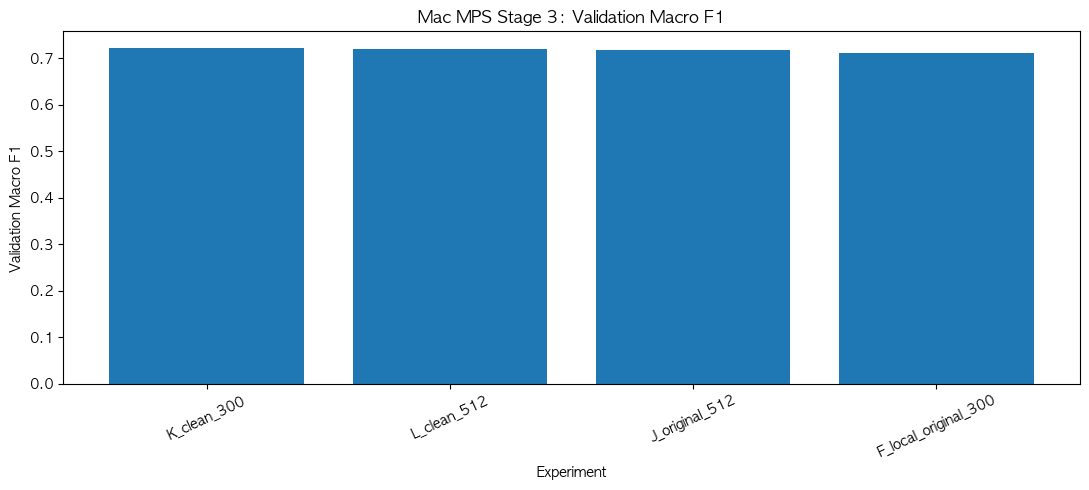

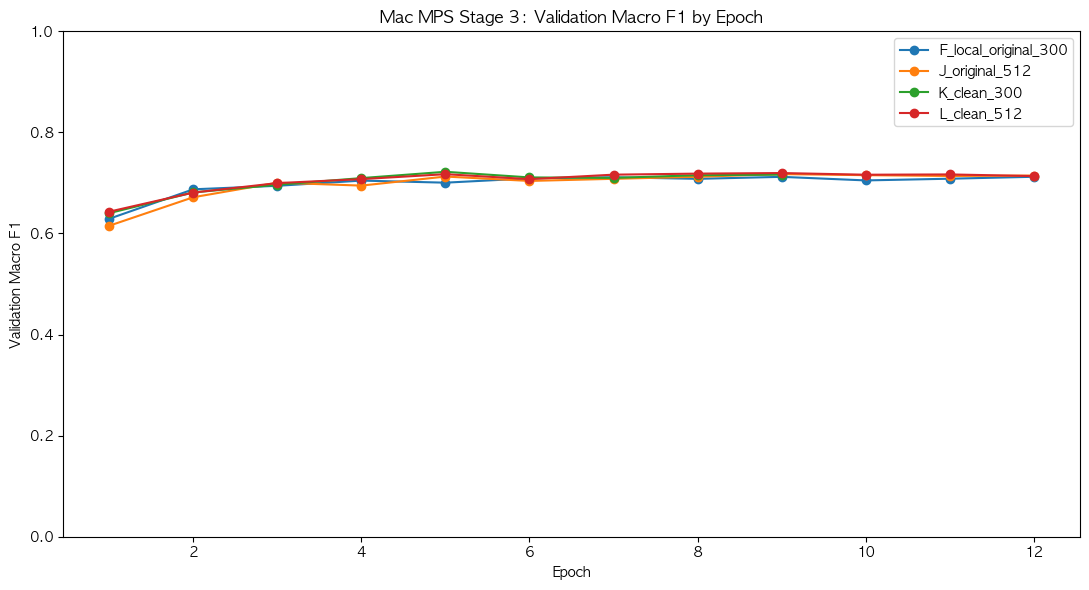

In [14]:
plt.figure(figsize=(11, 5))

plt.bar(
    validation_results_df[
        "experiment"
    ],
    validation_results_df[
        "val_macro_f1"
    ],
)

plt.title(
    "Mac MPS Stage 3: "
    "Validation Macro F1"
)
plt.xlabel("Experiment")
plt.ylabel("Validation Macro F1")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 6))

for (
    experiment_name,
    history,
) in experiment_histories.items():
    epochs = range(
        1,
        len(
            history["val_macro_f1"]
        ) + 1,
    )

    plt.plot(
        epochs,
        history["val_macro_f1"],
        marker="o",
        label=experiment_name,
    )

plt.title(
    "Mac MPS Stage 3: "
    "Validation Macro F1 by Epoch"
)
plt.xlabel("Epoch")
plt.ylabel("Validation Macro F1")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 14. Validation 기준 최종 후보 선택

F-local·J·K·L 중 validation Macro F1이 가장 높은 모델만 test에서 평가합니다.

In [15]:
best_validation_row = (
    validation_results_df.iloc[0]
)
best_experiment_name = (
    best_validation_row[
        "experiment"
    ]
)

print(
    "Validation 기준 최종 후보:",
    best_experiment_name,
)
print(
    "Validation Macro F1:",
    f"{best_validation_row['val_macro_f1']:.4f}",
)
print(
    "Best epoch:",
    int(
        best_validation_row[
            "best_epoch"
        ]
    ),
)

Validation 기준 최종 후보: K_clean_300
Validation Macro F1: 0.7221
Best epoch: 5


## 15. 최종 후보 Test 평가

In [16]:
best_resource = (
    experiment_resources[
        best_experiment_name
    ]
)

_, _, best_test_loader = (
    best_resource["loaders"]
)

final_model = PackedAttentionBiGRU(
    embedding_matrix=best_resource[
        "embedding_matrix"
    ],
    hidden_dim=HIDDEN_DIM,
    num_classes=len(target_names),
).to(DEVICE)

best_checkpoint_path = Path(
    best_validation_row[
        "checkpoint_path"
    ]
)

final_model.load_state_dict(
    load_state_dict_compat(
        best_checkpoint_path
    )
)

final_criterion = nn.CrossEntropyLoss(
    label_smoothing=LABEL_SMOOTHING
)

(
    final_test_loss,
    final_test_metrics,
    final_test_labels,
    final_test_predictions,
) = evaluate_model(
    final_model,
    best_test_loader,
    final_criterion,
)

final_test_record = {
    "experiment": (
        best_experiment_name
    ),
    "preprocessing": (
        best_resource[
            "preprocessing"
        ]
    ),
    "max_len": int(
        best_resource["max_len"]
    ),
    "test_loss": float(
        final_test_loss
    ),
    **final_test_metrics,
}

final_test_df = pd.DataFrame(
    [final_test_record]
)

display(
    final_test_df.style.format(
        {
            "test_loss": "{:.4f}",
            "accuracy": "{:.4f}",
            "macro_precision": "{:.4f}",
            "macro_recall": "{:.4f}",
            "macro_f1": "{:.4f}",
        }
    )
)

final_test_df.to_csv(
    RESULT_DIR
    / "mps_stage3_final_test.csv",
    index=False,
)

validation_results_df.to_csv(
    RESULT_DIR
    / "mps_stage3_validation_results.csv",
    index=False,
)

diagnostics_df.to_csv(
    RESULT_DIR
    / "mps_stage3_data_diagnostics.csv",
    index=False,
)

,experiment,preprocessing,max_len,test_loss,accuracy,macro_precision,macro_recall,macro_f1
0,K_clean_300,clean,300,1.2868,0.7262,0.7288,0.7160,0.7170


## 16. Class별 report와 confusion matrix

,precision,recall,f1-score,support
talk.religion.misc,0.4737,0.3830,0.4235,94
talk.politics.misc,0.6552,0.4914,0.5616,116
alt.atheism,0.5758,0.6333,0.6032,120
talk.politics.guns,0.6639,0.5766,0.6172,137
comp.os.ms-windows.misc,0.7188,0.6216,0.6667,148
sci.med,0.5410,0.8919,0.6735,148
comp.sys.ibm.pc.hardware,0.6331,0.7279,0.6772,147
comp.graphics,0.6358,0.7534,0.6897,146
sci.electronics,0.7266,0.6824,0.7038,148
misc.forsale,0.7787,0.6463,0.7063,147


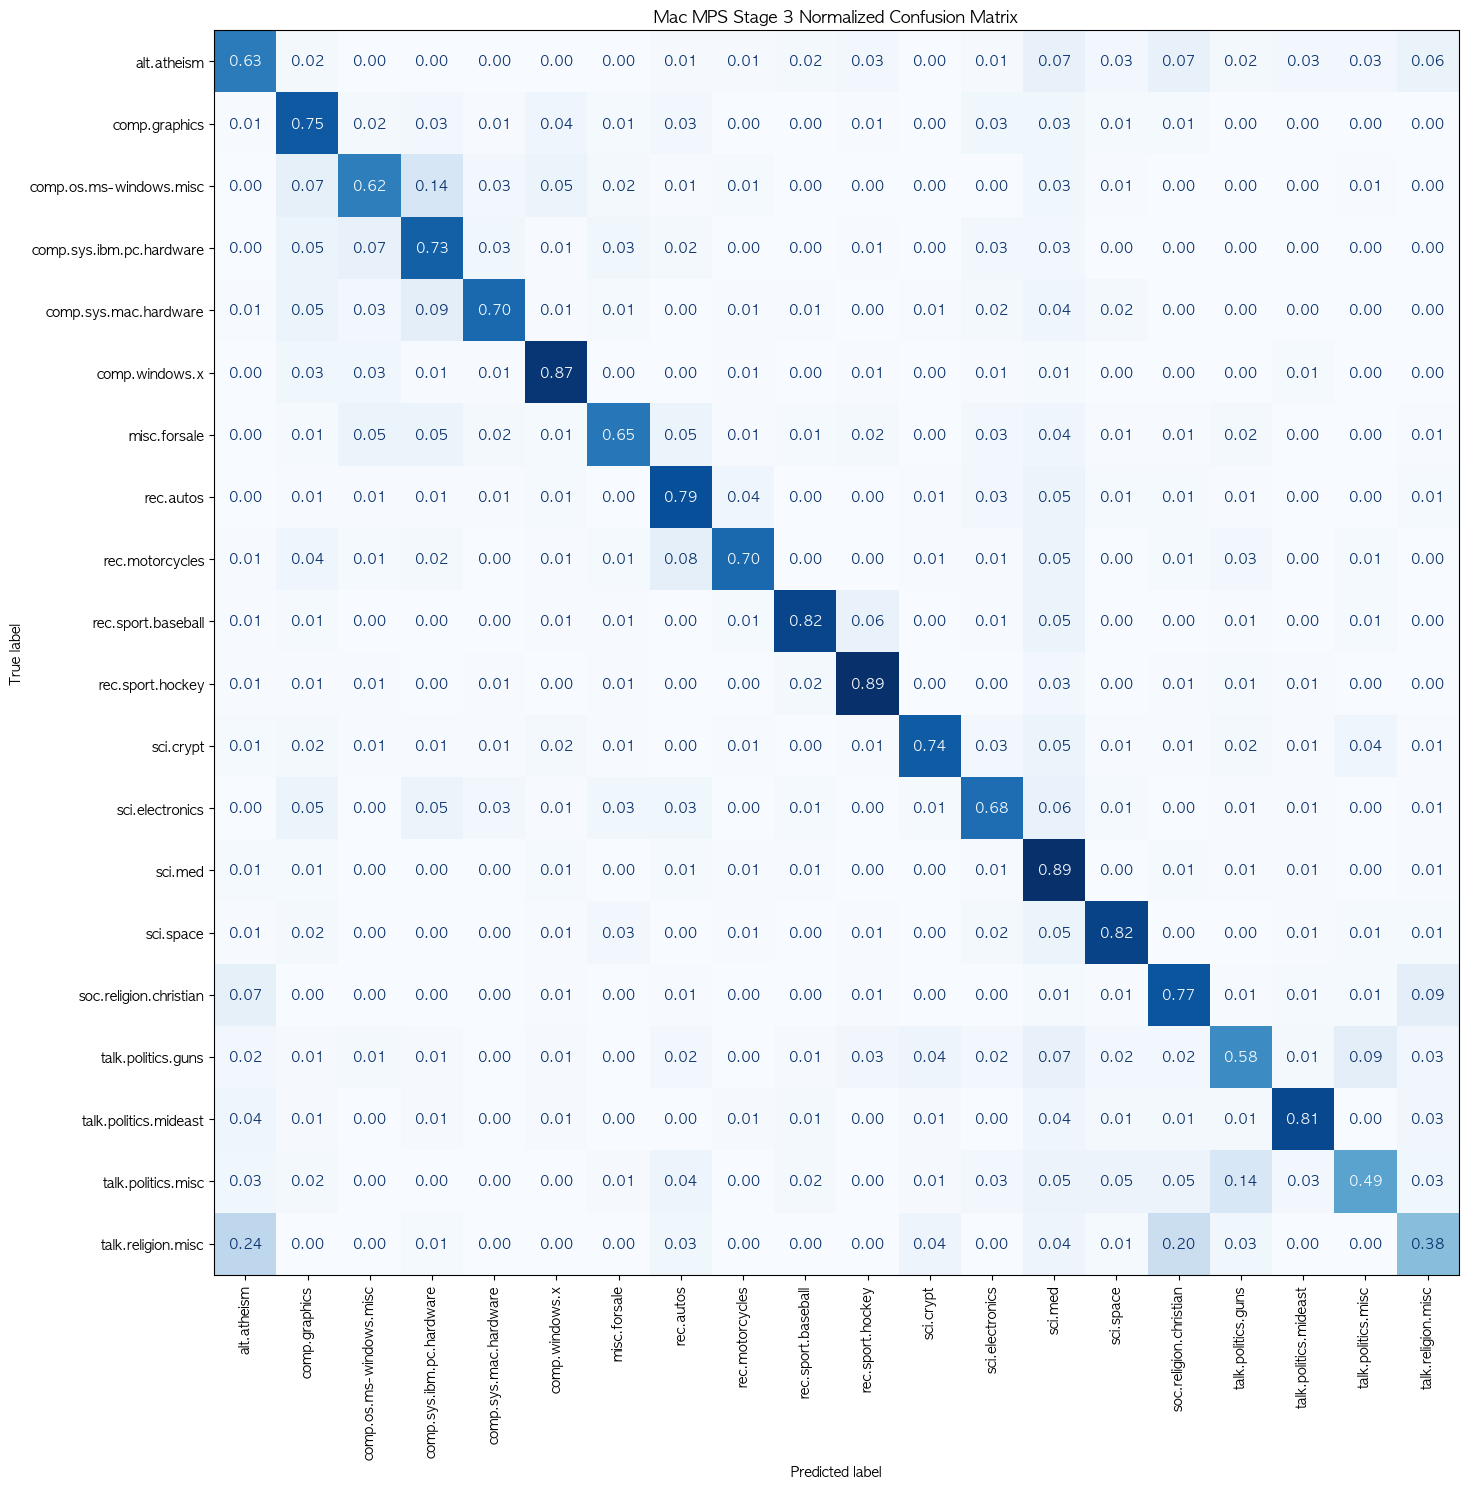

In [17]:
final_report = classification_report(
    final_test_labels,
    final_test_predictions,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

final_class_report_df = (
    pd.DataFrame(final_report)
    .T
    .loc[
        target_names,
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ],
    ]
    .sort_values("f1-score")
)

display(
    final_class_report_df.style.format(
        {
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1-score": "{:.4f}",
            "support": "{:.0f}",
        }
    )
)

normalized_cm = confusion_matrix(
    final_test_labels,
    final_test_predictions,
    normalize="true",
)

fig, ax = plt.subplots(
    figsize=(15, 15)
)

ConfusionMatrixDisplay(
    confusion_matrix=normalized_cm,
    display_labels=target_names,
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format=".2f",
    colorbar=False,
)

plt.title(
    "Mac MPS Stage 3 "
    "Normalized Confusion Matrix"
)
plt.tight_layout()
plt.show()

## 17. 자동 결론

J·K·L을 F-local과 비교해 데이터 개선 효과를 자동 해석합니다.

In [18]:
result_lookup = (
    validation_results_df
    .set_index("experiment")
)

f_local_f1 = result_lookup.loc[
    "F_local_original_300",
    "val_macro_f1",
]
j_f1 = result_lookup.loc[
    "J_original_512",
    "val_macro_f1",
]
k_f1 = result_lookup.loc[
    "K_clean_300",
    "val_macro_f1",
]
l_f1 = result_lookup.loc[
    "L_clean_512",
    "val_macro_f1",
]

summary_lines = [
    "## Mac MPS 3차 실험 결론",
    "",
    (
        f"- Validation 최종 후보: "
        f"**{best_experiment_name}**"
    ),
    (
        f"- Validation Macro F1: "
        f"**{best_validation_row['val_macro_f1']:.4f}**"
    ),
    (
        f"- Test Accuracy: "
        f"**{final_test_metrics['accuracy']:.4f}**"
    ),
    (
        f"- Test Macro F1: "
        f"**{final_test_metrics['macro_f1']:.4f}**"
    ),
    "",
    "### Ablation 변화",
    (
        f"- J vs F-local, 512 token 효과: "
        f"**{j_f1 - f_local_f1:+.4f}**"
    ),
    (
        f"- K vs F-local, noise 제거 효과: "
        f"**{k_f1 - f_local_f1:+.4f}**"
    ),
    (
        f"- L vs K, clean corpus에서 512 효과: "
        f"**{l_f1 - k_f1:+.4f}**"
    ),
    (
        f"- L vs J, 512 조건의 cleaning 효과: "
        f"**{l_f1 - j_f1:+.4f}**"
    ),
]

if j_f1 > f_local_f1:
    summary_lines.append(
        "- 문서 후반 정보가 유효해 "
        "sequence budget 확장이 도움이 되었습니다."
    )
else:
    summary_lines.append(
        "- 512 token 확장만으로는 "
        "validation 성능이 개선되지 않았습니다."
    )

if k_f1 > f_local_f1:
    summary_lines.append(
        "- encoded noise 제거와 정제 FastText가 "
        "300 token 조건에서 효과가 있었습니다."
    )
else:
    summary_lines.append(
        "- 현재 cleaning 규칙은 300 token 조건에서 "
        "명확한 이득을 만들지 못했습니다."
    )

if l_f1 == max(
    f_local_f1,
    j_f1,
    k_f1,
    l_f1,
):
    summary_lines.append(
        "- cleaning과 512 token을 결합한 L이 "
        "가장 좋은 validation 결과를 냈습니다."
    )

display(
    Markdown(
        "\n".join(summary_lines)
    )
)

summary_path = (
    RESULT_DIR
    / "mps_stage3_summary.md"
)

summary_path.write_text(
    "\n".join(summary_lines),
    encoding="utf-8",
)

print(
    "결과 저장 위치:",
    RESULT_DIR.resolve(),
)

## Mac MPS 3차 실험 결론

- Validation 최종 후보: **K_clean_300**
- Validation Macro F1: **0.7221**
- Test Accuracy: **0.7262**
- Test Macro F1: **0.7170**

### Ablation 변화
- J vs F-local, 512 token 효과: **+0.0053**
- K vs F-local, noise 제거 효과: **+0.0099**
- L vs K, clean corpus에서 512 효과: **-0.0025**
- L vs J, 512 조건의 cleaning 효과: **+0.0021**
- 문서 후반 정보가 유효해 sequence budget 확장이 도움이 되었습니다.
- encoded noise 제거와 정제 FastText가 300 token 조건에서 효과가 있었습니다.

결과 저장 위치: /Users/pio/Documents/AIENGINEERCOURSE/sprint_mission/mission10/mission10_stage3_mps_outputs/results


## 18. 실행 결과 해석 체크리스트

- **J > F-local**  
  문서 뒤쪽 token이 유효했습니다.

- **K > F-local**  
  encoded payload가 embedding과 classifier를 방해했습니다.

- **L > K**  
  clean corpus에서도 긴 문서가 추가 정보를 제공했습니다.

- **L > J**  
  동일 512 token에서 cleaning 효과가 있었습니다.

- **세 모델 모두 F-local 이하**  
  현재 병목은 단순 길이와 encoded noise보다 category 간 semantic overlap일 가능성이 큽니다.

## Colab 결과와 비교할 때의 주의

Colab F의 Test Macro F1 `0.7191`은 참고값일 뿐입니다.  
로컬 MPS 결과와의 직접 차이는 MPS 자체의 효과가 아니라 다음 요소가 섞인 값입니다.

- FastText CPU threading
- PyTorch version
- hardware backend
- floating-point 연산 순서
- mini-batch 구성과 gradient accumulation

최종 연구 결론은 같은 local environment에서 재학습한 F-local·J·K·L의 validation 비교를 우선합니다.